<a href="https://colab.research.google.com/github/kartikeyabekkari/HyperRealisticNisqSimulation/blob/main/Hyper_Realistic_NISQ_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup & Imports



In [2]:
!pip install --upgrade --force-reinstall cirq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.7/733.7 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.5/176.5 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import warnings
warnings.filterwarnings("ignore")


try:
    import cirq
except ImportError:
    print("installing cirq...")
    !pip install cirq --quiet
    import cirq
    print("installed cirq.")


import matplotlib.pyplot as plt
import cirq_web
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
deg = np.radians

print("Libraries Imported Successfully!")

Libraries Imported Successfully!




---


#Parameters





In [2]:
import cirq
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
deg = np.radians

---
#Divider
---

In [18]:
#================= Parameters =================

number_of_qubits_in_the_circuit = 2
number_of_runs = 2000
distance_between_qubits = 2  # micrometers

base_noise = 0.00001

single_qubit_noise = 0.00036
single_qubit_plus_minus = 0.00029

multi_qubit_noise = 0.0033
multi_qubit_plus_minus = 0.0018

readout_noise = 0.0077
readout_noise_plus_minus = 0.0021

amplitude_damp_chance = 0.00092647
#================= Build Circuit =================
qubits = cirq.LineQubit.range(number_of_qubits_in_the_circuit)
base_circuit = cirq.Circuit([
#-------------------------------------------------
cirq.H(qubits[0]),
cirq.CNOT(qubits[0],qubits[1]),
cirq.measure(qubits, key='result'),
#------------------ Edit Here ^ ------------------
])

print(f"Your Circuit:\n\n{base_circuit}\n")

Your Circuit:

0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────



---
#Functions
---

In [46]:
from cirq.ops.parity_gates import YYPowGate
SINGLE_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
)
MULTI_GATE_TYPES = (
    cirq.CXPowGate,
    cirq.CYPowGate,
    cirq.CZPowGate,
    cirq.XXPowGate,
    cirq.YYPowGate,
    cirq.ZZPowGate,
    cirq.CCNotPowGate,
    cirq.CCXPowGate,
    cirq.CCYPowGate,
    cirq.CCZPowGate,
    cirq.ISwapPowGate,
    cirq.SwapPowGate,
)

#---------- error values for each type of gate ----------
readout_error_nums = [(max(0,readout_noise-readout_noise_plus_minus)),readout_noise,(min(1,readout_noise+readout_noise_plus_minus))]
multi_gate_error_nums = [(max(0, multi_qubit_noise-multi_qubit_plus_minus)),multi_qubit_noise,(min(1,multi_qubit_noise+multi_qubit_plus_minus))] # Ensured the lower bound is not negative
single_gate_error_nums = [(max(0,single_qubit_noise-single_qubit_plus_minus)),single_qubit_noise,(min(1,single_qubit_noise+single_qubit_plus_minus))]

def build_shot_circuit(original_circuit, all_qubits):
    circuit = cirq.Circuit()

    num_moments = len(original_circuit)

    for i, moment in enumerate(original_circuit):
        circuit.append(moment)

        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            continue

        single_loud_qubits = {
            q for op in moment if isinstance(op.gate, SINGLE_GATE_TYPES) for q in op.qubits}
        multi_loud_qubits = {
            q for op in moment if isinstance(op.gate, MULTI_GATE_TYPES) for q in op.qubits}

        bit_flip_ops = []
        depolarize_ops = []
        flipped_qubit_indices = []

        for q_idx, q in enumerate(all_qubits):
            if q in multi_loud_qubits:
              error_rate = random.choice(multi_gate_error_nums)
            elif q in single_loud_qubits:
              error_rate = random.choice(single_gate_error_nums)
            else:
              error_rate = base_noise

            bit_flip_ops.append(cirq.bit_flip(p=error_rate)(q))
            depolarize_ops.append(cirq.depolarize(p=error_rate)(q))

            if np.random.rand() < error_rate:
                flipped_qubit_indices.append(q_idx)

        #circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(amplitude_damp_chance)(q) for q in all_qubits))

        # --- Crosstalk made with the flip idx above ---

        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0  # this qubit already flipped, therefore treat as certain
            elif flipped_qubit_indices:
                distance = [
                    abs(q_idx - flipped_idx) * distance_between_qubits for flipped_idx in flipped_qubit_indices]
                shortest_distance = min(distance)



                crosstalk_p = 1.0 / (shortest_distance*distance_between_qubits ** 4)  # Needs edits



            else:
              # no flip happend in the whole moment, no opportunity for crosstalk
                crosstalk_p = 0.0

            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))


        if i == num_moments - 2:
            circuit.append(cirq.bit_flip(random.choice(readout_error_nums)).on_each(qubits))

    return circuit
# ================= Simulate + collect results =================
total_counts = Counter()


def simulate(circuit, type_of_noise=None):
    #Runs circuit once (1 shot) and adds the result into total_counts
    sim = cirq.Simulator()
    result = sim.run(circuit)
    total_counts.update(result.histogram(key='result'))


def graph(num_qubits, num_runs):
    # Creates bar chart
    print("\n--- SIMULATION RESULTS ---\n")

    total_possible_states = 2 ** num_qubits
    labels, values = [], []
    for outcome in range(total_possible_states):
        binary_string = format(outcome, f"0{num_qubits}b")
        labels.append(binary_string)
        actual_count = total_counts.get(outcome, 0)
        values.append(actual_count)
        print(f"State |{binary_string}⟩: {actual_count} times ~ {(actual_count / num_runs) * 100:.2f}%")

    plt.figure(figsize=(1 + 2 * num_qubits, 6))
    plt.bar(labels, values, color="lightblue", edgecolor="lightblue")
    plt.title(f"Total For {num_runs} Procedural Runs")
    plt.xlabel("Quantum States")
    plt.ylabel("Total Count")
    plt.xticks(rotation=315, fontsize=8)
    plt.grid(axis="y", linestyle="--", alpha=0.85)
    plt.tight_layout()
    plt.show()


def run_NISQ_simulation(circuit_template, all_qubits, num_runs):
    # defines how to run
    total_counts.clear()
    print(f'Circuit:\n{base_circuit}')
    for _ in range(num_runs):
        shot_circuit = build_shot_circuit(circuit_template, all_qubits)
        #print(f'{shot_circuit}\n\n\n')
        simulate(shot_circuit)
    graph(len(all_qubits), num_runs)

---
# Run the circuit
---

Circuit:
0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────

--- SIMULATION RESULTS ---

State |00⟩: 990 times ~ 49.50%
State |01⟩: 27 times ~ 1.35%
State |10⟩: 31 times ~ 1.55%
State |11⟩: 952 times ~ 47.60%


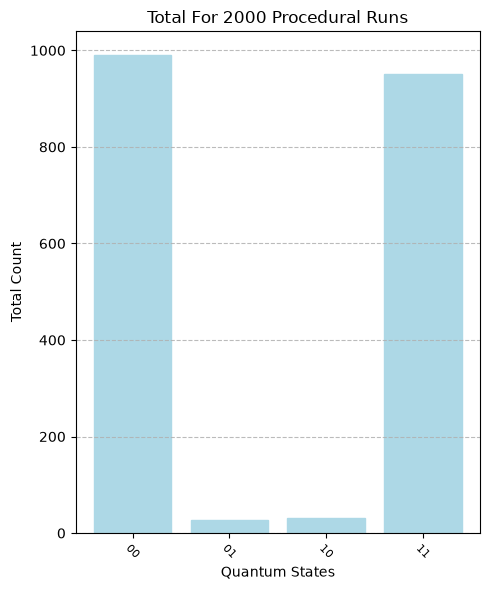

In [47]:
run_NISQ_simulation(base_circuit, qubits, number_of_runs)

#
---

#Divider 2


In [43]:
from __future__ import annotations

from dataclasses import dataclass

import cirq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SINGLE_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
)
MULTI_GATE_TYPES = (
    cirq.CXPowGate,
    cirq.CYPowGate,
    cirq.CZPowGate,
    cirq.XXPowGate,
    cirq.YYPowGate,
    cirq.ZZPowGate,
    cirq.CCNotPowGate,
    cirq.CCXPowGate,
    cirq.CCYPowGate,
    cirq.CCZPowGate,
    cirq.ISwapPowGate,
    cirq.SwapPowGate,
)

# Fixes every source of randomness in this script (data generation, the
# train/holdout split, class balancing, and the classifier itself) so
# re-running produces the SAME result every time instead of a different
# one. Change this value if you deliberately want to test a different
# random realization.
RANDOM_SEED = 75


@dataclass
class NoiseConfig:
    name: str
    base_noise: float          # background error rate on idle qubits
    single_gate_noise: float
    multi_gate_noise: float         # error rate on actively-driven qubits
    readout_noise: float
    amplitude_damp_chance: float
    distance_between_qubits: float  # micrometers; smaller = stronger crosstalk


# "Low error percentage" baseline -- bulk of the training data.
LOW_NOISE_CONFIG = NoiseConfig(
    name="low_noise_baseline",
    base_noise=0.00005,
    single_gate_noise=0.0002,
    multi_gate_noise=0.002,
    readout_noise = 0.00077,
    amplitude_damp_chance=0.00002,
    distance_between_qubits=4,
)

# Higher, more realistic error rates -- mimics an actual NISQ device.
# Placeholder scale-up until calibrated against real hardware data.
REAL_WORLD_CONFIG = NoiseConfig(
    name="real_world_nisq",
    base_noise=0.02,
    single_gate_noise=0.1,
    multi_gate_noise = 0.15,
    readout_noise= 0.15,
    amplitude_damp_chance=0.001,
    distance_between_qubits=2,
)


# ================= Noise + crosstalk model (same as nisq_corrected.py) =================
def build_shot_circuit(original_circuit, all_qubits, config: NoiseConfig):
    """Builds one noisy shot circuit under the given NoiseConfig."""
    circuit = cirq.Circuit()
    num_moment = len(original_circuit)
    for i, moment in enumerate(original_circuit):
        circuit.append(moment)
        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            continue

        single_gate_qubits = {
            q for op in moment if isinstance(op.gate, SINGLE_GATE_TYPES) for q in op.qubits
        }
        multi_gate_qubits = {
            q for op in moment if isinstance(op.gate, MULTI_GATE_TYPES) for q in op.qubits
        }

        bit_flip_ops, depolarize_ops, flipped_qubit_indices = [], [], []
        for q_idx, q in enumerate(all_qubits):
            if q in single_gate_qubits:
              rate= config.single_gate_noise
            elif q in multi_gate_qubits:
              rate= config.multi_gate_noise
            else:
               config.base_noise
            bit_flip_ops.append(cirq.bit_flip(p=rate)(q))
            depolarize_ops.append(cirq.depolarize(p=rate)(q))
            if np.random.rand() < rate:
                flipped_qubit_indices.append(q_idx)

        #circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(config.amplitude_damp_chance)(q) for q in all_qubits))

        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0
            elif flipped_qubit_indices:
                distances = [
                    abs(q_idx - flipped_idx) * config.distance_between_qubits
                    for flipped_idx in flipped_qubit_indices
                ]
                shortest = max(min(distances), 1e-9)
                crosstalk_p = min(1.0, 1.0 / (shortest ** 2))
            else:
                crosstalk_p = 0.0
            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))
        if i == num_moment -2:
          circuit.append(cirq.bit_flip(config.readout_noise).on_each(qubits))

    return circuit


# ================= Dataset generation =================
def generate_dataset(base_circuit, qubits, config: NoiseConfig, num_samples: int, ideal_simulator=None):
    """
    Returns (X, y):
      X = [base_noise, high_noise, amplitude_damp_chance, distance_between_qubits, *noisy_bitstring]
      y = ideal_bitstring (ground truth, from the noiseless circuit)

    Note: the bitstrings here have as many bits as are actually measured
    by `base_circuit` (its `cirq.measure(..., key='result')` operation),
    which is NOT necessarily the same as len(qubits) -- a circuit can use
    extra "helper" qubits internally that are never measured.
    """
    ideal_simulator = ideal_simulator or cirq.Simulator()
    noisy_simulator = cirq.Simulator()
    config_features = [
        config.base_noise,
        config.single_gate_noise,
        config.multi_gate_noise,
        config.readout_noise,
        config.amplitude_damp_chance,
        config.distance_between_qubits,
    ]

    X_rows, y_rows = [], []
    for _ in range(num_samples):
        shot_circuit = build_shot_circuit(base_circuit, qubits, config)
        noisy_bits = noisy_simulator.run(shot_circuit).measurements['result'][0]
        ideal_bits = ideal_simulator.run(base_circuit).measurements['result'][0]

        X_rows.append(config_features + list(noisy_bits))
        y_rows.append(list(ideal_bits))

    return np.array(X_rows, dtype=float), np.array(y_rows, dtype=float)


def bitstring_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Fraction of samples where EVERY bit matches the ideal bitstring."""
    return float(np.mean(np.all(y_true == y_pred, axis=1)))


def per_bit_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """Per-qubit accuracy, useful for seeing which qubits are hardest to correct."""
    return np.mean(y_true == y_pred, axis=0)


def bits_to_state_indices(bit_rows: np.ndarray) -> np.ndarray:
    """Converts an (N, num_qubits) array of 0/1 rows into an (N,) array of integer state indices."""
    num_qubits = bit_rows.shape[1]
    weights = 2 ** np.arange(num_qubits - 1, -1, -1)
    return bit_rows.astype(int).dot(weights)


def state_indices_to_bits(state_indices: np.ndarray, num_qubits: int) -> np.ndarray:
    """Inverse of bits_to_state_indices: turns integer class labels back into 0/1 bit rows."""
    rows = [[int(b) for b in format(int(idx), f"0{num_qubits}b")] for idx in state_indices]
    return np.array(rows, dtype=float)


def balance_classes(X: np.ndarray, y_labels: np.ndarray, random_state: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """
    Oversamples (with replacement) every class up to the size of the
    largest class, so the model can't learn "predict the more common
    outcome" as a shortcut. Without this, whichever ideal state happens
    to be slightly more frequent in a given (unseeded) data-generation
    run gets treated as the default answer, which is what causes the
    asymmetric over/under-correction between |0000> and |1111>.
    """
    rng = np.random.default_rng(random_state)
    unique_labels, counts = np.unique(y_labels, return_counts=True)
    target_count = counts.max()

    balanced_idx = []
    for label in unique_labels:
        idx_for_label = np.where(y_labels == label)[0]
        sampled_idx = rng.choice(idx_for_label, size=target_count, replace=True)
        balanced_idx.append(sampled_idx)
    balanced_idx = np.concatenate(balanced_idx)
    rng.shuffle(balanced_idx)

    return X[balanced_idx], y_labels[balanced_idx]


def plot_before_after_histograms(y_ideal: np.ndarray, y_noisy: np.ndarray, y_corrected: np.ndarray, num_qubits: int):
    """
    Side-by-side histograms over every computational basis state,
    comparing the ideal distribution against the raw noisy results
    (before correction) and the ML-corrected results (after correction).
    Same y-axis scale on both so the improvement is visually comparable.
    """
    num_states = 2 ** num_qubits
    labels = [format(i, f"0{num_qubits}b") for i in range(num_states)]

    ideal_counts = np.bincount(bits_to_state_indices(y_ideal), minlength=num_states)
    noisy_counts = np.bincount(bits_to_state_indices(y_noisy), minlength=num_states)
    corrected_counts = np.bincount(bits_to_state_indices(y_corrected), minlength=num_states)

    y_max = max(ideal_counts.max(), noisy_counts.max(), corrected_counts.max()) * 1.15
    x = np.arange(num_states)
    width = 0.35

    fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax_before.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_before.bar(x + width / 2, noisy_counts, width, label="Raw noisy", color="lightcoral", edgecolor="black")
    ax_before.set_title("Before correction")
    ax_before.set_xlabel("Quantum state")
    ax_before.set_ylabel("Count")
    ax_before.set_xticks(x)
    ax_before.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_before.set_ylim(0, y_max)
    ax_before.legend()
    ax_before.grid(axis="y", linestyle="--", alpha=0.6)

    ax_after.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_after.bar(x + width / 2, corrected_counts, width, label="ML-corrected", color="lightgreen", edgecolor="black")
    ax_after.set_title("After correction")
    ax_after.set_xlabel("Quantum state")
    ax_after.set_xticks(x)
    ax_after.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_after.legend()
    ax_after.grid(axis="y", linestyle="--", alpha=0.6)

    fig.suptitle("Outcome distribution vs. ideal: before vs. after ML error correction\n(real-world-noise held-out test set)")
    plt.tight_layout()
    plt.show()


# ================= Main training + evaluation pipeline =================
def main():
    np.random.seed(RANDOM_SEED)  # makes data generation, noise draws, and sampling reproducible



    print(f'your circuit \n\n{base_circuit}\n')
    ideal_sim = cirq.Simulator()


    measured_qubits = [
        q for op in base_circuit.all_operations()
        if isinstance(op.gate, cirq.MeasurementGate)
        for q in op.qubits
    ]
    num_measured_qubits = len(measured_qubits)

    print("Generating LOW-noise training data (clean baseline)...")
    X_low, y_low = generate_dataset(base_circuit, qubits, LOW_NOISE_CONFIG, num_samples=2400, ideal_simulator=ideal_sim)

    print("Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...")
    X_real_train, y_real_train = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=600, ideal_simulator=ideal_sim)

    print("Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...")
    X_real_test, y_real_test = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=1000, ideal_simulator=ideal_sim)

    # Training set: mostly low-noise (the "low error percentage" data),
    # with a smaller slice of real-world-noise data mixed in so the model
    # has at least seen the harder error regime it'll be evaluated on.
    X_train = np.vstack([X_low, X_real_train])
    y_train = np.vstack([y_low, y_real_train])
    # Stratify by joint outcome state so the train/holdout split preserves
    # whatever class balance the generated data has, instead of letting
    # an unstratified random split shift it further.
    y_train_labels_full = bits_to_state_indices(y_train)
    X_train, X_holdout, y_train, y_holdout = train_test_split(
        X_train, y_train, test_size=0.15, random_state=0, stratify=y_train_labels_full
    )

    print(f"\nTraining samples: {len(X_train)}  (holdout: {len(X_holdout)}, real-world test: {len(X_real_test)})")

    print("Training MLP error-mitigation model...")
    # IMPORTANT: this circuit's ideal outcomes are perfectly correlated
    # across qubits -- so instead of training independent per-bit
    # classifiers (which have no way to know the bits are linked, and
    # whose small individual biases compound into wildly overcorrecting
    # toward one state), we train ONE classifier over the joint outcome
    # state. This lets the model learn the correct *proportional*
    # asymmetry from the noise model (e.g. amplitude damping only ever
    # pulling 1->0) instead of an all-or-nothing collapse.
    y_train_labels = bits_to_state_indices(y_train)

    # Balance classes so no single outcome is treated as the "default"
    # answer just because it happened to be slightly more common in this
    # (unseeded) data-generation run.
    X_train_balanced, y_train_labels_balanced = balance_classes(X_train, y_train_labels)

    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=0),
    )
    model.fit(X_train_balanced, y_train_labels_balanced)

    # --- Evaluate on the held-out real-world test set ---
    # FIX: slice off the last `num_measured_qubits` columns (not
    # `number_of_qubits`) since that's how many bits were actually measured.
    noisy_bits_test = X_real_test[:, -num_measured_qubits:]
    raw_acc = bitstring_accuracy(y_real_test, noisy_bits_test)

    corrected_labels_test = model.predict(X_real_test)
    # FIX: reconstruct bitstrings using num_measured_qubits, matching the
    # width of y_real_test.
    corrected_bits_test = state_indices_to_bits(corrected_labels_test, num_measured_qubits)
    corrected_acc = bitstring_accuracy(y_real_test, corrected_bits_test)

    raw_per_bit = per_bit_accuracy(y_real_test, noisy_bits_test)
    corrected_per_bit = per_bit_accuracy(y_real_test, corrected_bits_test)

    print("\n=== Real-world NISQ evaluation (held-out test set) ===")
    print(f"Raw noisy bitstring accuracy:       {raw_acc * 100:.2f}%")
    print(f"Model-corrected bitstring accuracy: {corrected_acc * 100:.2f}%")
    print(f"Improvement:                        {(corrected_acc - raw_acc) * 100:+.2f} percentage points\n")
    for i in range(num_measured_qubits):
        print(f"  qubit {i}: raw={raw_per_bit[i] * 100:5.2f}%  corrected={corrected_per_bit[i] * 100:5.2f}%")

    # --- Plots ---
    plot_before_after_histograms(y_real_test, noisy_bits_test, corrected_bits_test, num_measured_qubits)

    plt.figure(figsize=(5, 5))
    plt.bar(["Raw noisy", "ML-corrected"], [raw_acc * 100, corrected_acc * 100],
            color=["lightcoral", "lightgreen"], edgecolor="black")
    plt.ylabel("Full-bitstring accuracy vs. ideal (%)")
    plt.title("Error mitigation: raw vs. ML-corrected\n(evaluated on real-world-noise test set)")
    plt.ylim(0, 100)
    for i, v in enumerate([raw_acc * 100, corrected_acc * 100]):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()

your circuit 

0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       27.40%
Model-corrected bitstring accuracy: 49.90%
Improvement:                        +22.50 percentage points

  qubit 0: raw=49.10%  corrected=49.90%
  qubit 1: raw=49.00%  corrected=49.90%


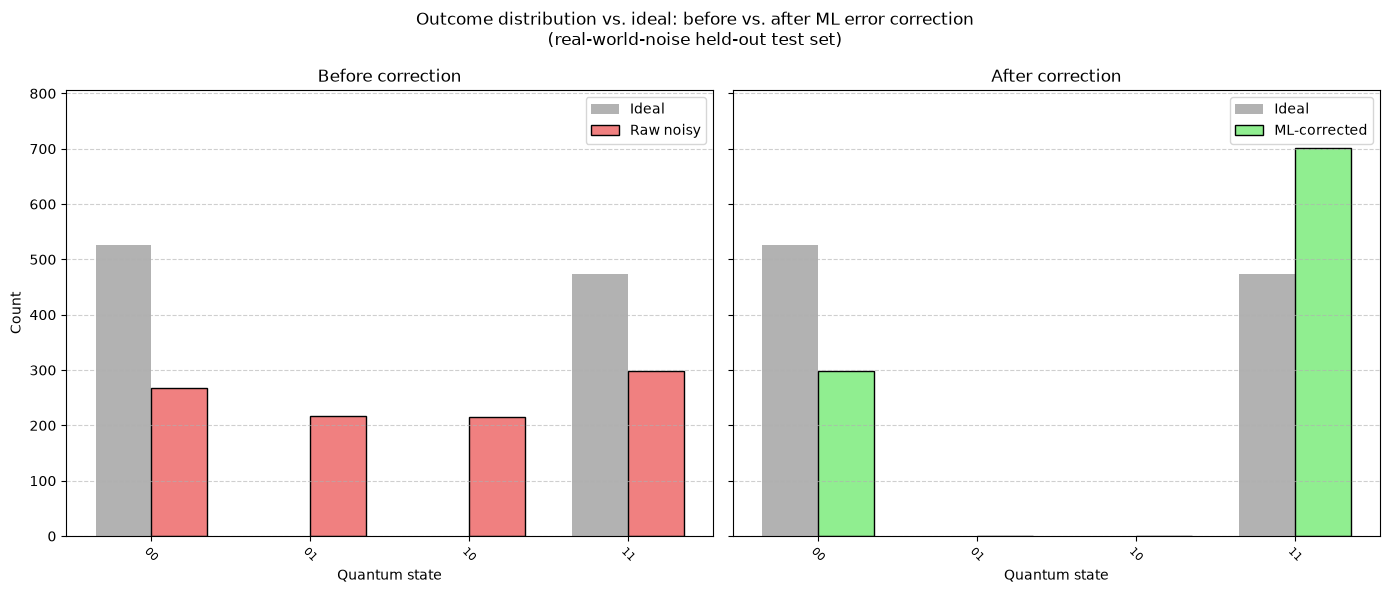

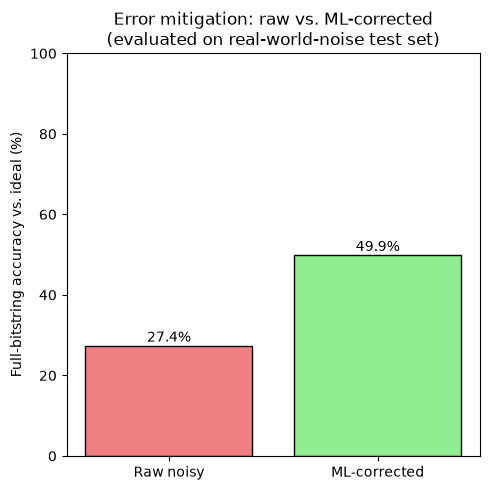

In [44]:
main()

#

In [1]:

from __future__ import annotations

from dataclasses import dataclass

import cirq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

LOUD_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
    cirq.CXPowGate,
    cirq.PhasedXPowGate,
)

# Fixes every source of randomness in this script (data generation, the
# train/holdout split, class balancing, and the classifier itself) so
# re-running produces the SAME result every time instead of a different
# one. Change this value if you deliberately want to test a different
# random realization.
RANDOM_SEED = 42


@dataclass
class NoiseConfig:
    name: str
    base_noise: float          # background error rate on idle qubits
    high_noise: float          # error rate on actively-driven qubits
    amplitude_damp_chance: float
    distance_between_qubits: float  # micrometers; smaller = stronger crosstalk


# "Low error percentage" baseline -- bulk of the training data.
LOW_NOISE_CONFIG = NoiseConfig(
    name="low_noise_baseline",
    base_noise=0.00005,
    high_noise=0.0002,
    amplitude_damp_chance=0.00002,
    distance_between_qubits=4,
)

# Higher, more realistic error rates -- mimics an actual NISQ device.
# Placeholder scale-up until calibrated against real hardware data.
REAL_WORLD_CONFIG = NoiseConfig(
    name="real_world_nisq",
    base_noise=0.02,
    high_noise=0.1,
    amplitude_damp_chance=0.001,
    distance_between_qubits=2,
)


# ================= Noise + crosstalk model (same as nisq_corrected.py) =================
def build_shot_circuit(original_circuit, all_qubits, config: NoiseConfig):
    """Builds one noisy shot circuit under the given NoiseConfig."""
    circuit = cirq.Circuit()
    for moment in original_circuit:
        circuit.append(moment)
        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            continue

        active_loud_qubits = {
            q for op in moment if isinstance(op.gate, LOUD_GATE_TYPES) for q in op.qubits
        }

        bit_flip_ops, depolarize_ops, flipped_qubit_indices = [], [], []
        for q_idx, q in enumerate(all_qubits):
            rate = config.high_noise if q in active_loud_qubits else config.base_noise
            bit_flip_ops.append(cirq.bit_flip(p=rate)(q))
            depolarize_ops.append(cirq.depolarize(p=rate)(q))
            if np.random.rand() < rate:
                flipped_qubit_indices.append(q_idx)

        #circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(config.amplitude_damp_chance)(q) for q in all_qubits))

        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0
            elif flipped_qubit_indices:
                distances = [
                    abs(q_idx - flipped_idx) * config.distance_between_qubits
                    for flipped_idx in flipped_qubit_indices
                ]
                shortest = max(min(distances), 1e-9)
                crosstalk_p = min(1.0, 1.0 / (shortest ** 2))
            else:
                crosstalk_p = 0.0
            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))

    return circuit


# ================= Dataset generation =================
def generate_dataset(base_circuit, qubits, config: NoiseConfig, num_samples: int, ideal_simulator=None):
    """
    Returns (X, y):
      X = [base_noise, high_noise, amplitude_damp_chance, distance_between_qubits, *noisy_bitstring]
      y = ideal_bitstring (ground truth, from the noiseless circuit)
    """
    ideal_simulator = ideal_simulator or cirq.Simulator()
    noisy_simulator = cirq.Simulator()
    config_features = [
        config.base_noise,
        config.high_noise,
        config.amplitude_damp_chance,
        config.distance_between_qubits,
    ]

    X_rows, y_rows = [], []
    for _ in range(num_samples):
        shot_circuit = build_shot_circuit(base_circuit, qubits, config)
        noisy_bits = noisy_simulator.run(shot_circuit).measurements['result'][0]
        ideal_bits = ideal_simulator.run(base_circuit).measurements['result'][0]

        X_rows.append(config_features + list(noisy_bits))
        y_rows.append(list(ideal_bits))

    return np.array(X_rows, dtype=float), np.array(y_rows, dtype=float)


def bitstring_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Fraction of samples where EVERY bit matches the ideal bitstring."""
    return float(np.mean(np.all(y_true == y_pred, axis=1)))


def per_bit_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """Per-qubit accuracy, useful for seeing which qubits are hardest to correct."""
    return np.mean(y_true == y_pred, axis=0)


def bits_to_state_indices(bit_rows: np.ndarray) -> np.ndarray:
    """Converts an (N, num_qubits) array of 0/1 rows into an (N,) array of integer state indices."""
    num_qubits = bit_rows.shape[1]
    weights = 2 ** np.arange(num_qubits - 1, -1, -1)
    return bit_rows.astype(int).dot(weights)


def state_indices_to_bits(state_indices: np.ndarray, num_qubits: int) -> np.ndarray:
    """Inverse of bits_to_state_indices: turns integer class labels back into 0/1 bit rows."""
    rows = [[int(b) for b in format(int(idx), f"0{num_qubits}b")] for idx in state_indices]
    return np.array(rows, dtype=float)


def balance_classes(X: np.ndarray, y_labels: np.ndarray, random_state: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """
    Oversamples (with replacement) every class up to the size of the
    largest class, so the model can't learn "predict the more common
    outcome" as a shortcut. Without this, whichever ideal state happens
    to be slightly more frequent in a given (unseeded) data-generation
    run gets treated as the default answer, which is what causes the
    asymmetric over/under-correction between |0000> and |1111>.
    """
    rng = np.random.default_rng(random_state)
    unique_labels, counts = np.unique(y_labels, return_counts=True)
    target_count = counts.max()

    balanced_idx = []
    for label in unique_labels:
        idx_for_label = np.where(y_labels == label)[0]
        sampled_idx = rng.choice(idx_for_label, size=target_count, replace=True)
        balanced_idx.append(sampled_idx)
    balanced_idx = np.concatenate(balanced_idx)
    rng.shuffle(balanced_idx)

    return X[balanced_idx], y_labels[balanced_idx]


def plot_before_after_histograms(y_ideal: np.ndarray, y_noisy: np.ndarray, y_corrected: np.ndarray, num_qubits: int):
    """
    Side-by-side histograms over every computational basis state (|0000>
    ... |1111>), comparing the ideal distribution against the raw noisy
    results (before correction) and the ML-corrected results (after
    correction). Same y-axis scale on both so the improvement is visually
    comparable.
    """
    num_states = 2 ** num_qubits
    labels = [format(i, f"0{num_qubits}b") for i in range(num_states)]

    ideal_counts = np.bincount(bits_to_state_indices(y_ideal), minlength=num_states)
    noisy_counts = np.bincount(bits_to_state_indices(y_noisy), minlength=num_states)
    corrected_counts = np.bincount(bits_to_state_indices(y_corrected), minlength=num_states)

    y_max = max(ideal_counts.max(), noisy_counts.max(), corrected_counts.max()) * 1.15
    x = np.arange(num_states)
    width = 0.35

    fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax_before.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_before.bar(x + width / 2, noisy_counts, width, label="Raw noisy", color="lightcoral", edgecolor="black")
    ax_before.set_title("Before correction")
    ax_before.set_xlabel("Quantum state")
    ax_before.set_ylabel("Count")
    ax_before.set_xticks(x)
    ax_before.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_before.set_ylim(0, y_max)
    ax_before.legend()
    ax_before.grid(axis="y", linestyle="--", alpha=0.6)

    ax_after.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_after.bar(x + width / 2, corrected_counts, width, label="ML-corrected", color="lightgreen", edgecolor="black")
    ax_after.set_title("After correction")
    ax_after.set_xlabel("Quantum state")
    ax_after.set_xticks(x)
    ax_after.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_after.legend()
    ax_after.grid(axis="y", linestyle="--", alpha=0.6)

    fig.suptitle("Outcome distribution vs. ideal: before vs. after ML error correction\n(real-world-noise held-out test set)")
    plt.tight_layout()
    plt.show()


# ================= Main training + evaluation pipeline =================
def main():
    np.random.seed(RANDOM_SEED)  # makes data generation, noise draws, and sampling reproducible

    number_of_qubits = 42
    qubits = cirq.LineQubit.range(number_of_qubits)
    base_circuit = cirq.Circuit([
        cirq.H(qubits[0]),
        cirq.CNOT(qubits[0], qubits[1]),
        cirq.measure(*qubits, key='result'),
    ])

    ideal_sim = cirq.Simulator()

    print("Generating LOW-noise training data (clean baseline)...")
    X_low, y_low = generate_dataset(base_circuit, qubits, LOW_NOISE_CONFIG, num_samples=2400, ideal_simulator=ideal_sim)

    print("Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...")
    X_real_train, y_real_train = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=600, ideal_simulator=ideal_sim)

    print("Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...")
    X_real_test, y_real_test = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=1000, ideal_simulator=ideal_sim)

    # Training set: mostly low-noise (the "low error percentage" data),
    # with a smaller slice of real-world-noise data mixed in so the model
    # has at least seen the harder error regime it'll be evaluated on.
    X_train = np.vstack([X_low, X_real_train])
    y_train = np.vstack([y_low, y_real_train])
    # Stratify by joint outcome state so the train/holdout split preserves
    # whatever class balance the generated data has, instead of letting
    # an unstratified random split shift it further.
    y_train_labels_full = bits_to_state_indices(y_train)
    X_train, X_holdout, y_train, y_holdout = train_test_split(
        X_train, y_train, test_size=0.15, random_state=0, stratify=y_train_labels_full
    )

    print(f"\nTraining samples: {len(X_train)}  (holdout: {len(X_holdout)}, real-world test: {len(X_real_test)})")

    print("Training MLP error-mitigation model...")
    # IMPORTANT: this circuit's ideal outcomes are perfectly correlated
    # across qubits (only |0000> or |1111> are ever valid) -- so instead
    # of training 4 independent per-bit classifiers (which have no way to
    # know the bits are linked, and whose small individual biases compound
    # into wildly overcorrecting toward one state), we train ONE classifier
    # over the joint outcome state. This lets the model learn the correct
    # *proportional* asymmetry from the noise model (e.g. amplitude damping
    # only ever pulling 1->0) instead of an all-or-nothing collapse.
    y_train_labels = bits_to_state_indices(y_train)

    # Balance classes so neither |0000> nor |1111> is treated as the
    # "default" answer just because it happened to be slightly more
    # common in this (unseeded) data-generation run.
    X_train_balanced, y_train_labels_balanced = balance_classes(X_train, y_train_labels)

    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=0),
    )
    model.fit(X_train_balanced, y_train_labels_balanced)

    # --- Evaluate on the held-out real-world test set ---
    noisy_bits_test = X_real_test[:, -number_of_qubits:]
    raw_acc = bitstring_accuracy(y_real_test, noisy_bits_test)

    corrected_labels_test = model.predict(X_real_test)
    corrected_bits_test = state_indices_to_bits(corrected_labels_test, number_of_qubits)
    corrected_acc = bitstring_accuracy(y_real_test, corrected_bits_test)

    raw_per_bit = per_bit_accuracy(y_real_test, noisy_bits_test)
    corrected_per_bit = per_bit_accuracy(y_real_test, corrected_bits_test)

    print("\n=== Real-world NISQ evaluation (held-out test set) ===")
    print(f"Raw noisy bitstring accuracy:       {raw_acc * 100:.2f}%")
    print(f"Model-corrected bitstring accuracy: {corrected_acc * 100:.2f}%")
    print(f"Improvement:                        {(corrected_acc - raw_acc) * 100:+.2f} percentage points\n")
    for i in range(number_of_qubits):
        print(f"  qubit {i}: raw={raw_per_bit[i] * 100:5.2f}%  corrected={corrected_per_bit[i] * 100:5.2f}%")

    # --- Plots ---
    plot_before_after_histograms(y_real_test, noisy_bits_test, corrected_bits_test, number_of_qubits)

    plt.figure(figsize=(5, 5))
    plt.bar(["Raw noisy", "ML-corrected"], [raw_acc * 100, corrected_acc * 100],
            color=["lightcoral", "lightgreen"], edgecolor="black")
    plt.ylabel("Full-bitstring accuracy vs. ideal (%)")
    plt.title("Error mitigation: raw vs. ML-corrected\n(evaluated on real-world-noise test set)")
    plt.ylim(0, 100)
    for i, v in enumerate([raw_acc * 100, corrected_acc * 100]):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()



In [ ]:
main()


Generating LOW-noise training data (clean baseline)...


1 

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       47.00%
Model-corrected bitstring accuracy: 46.80%
Improvement:                        -0.20 percentage points

  qubit 0: raw=53.90%  corrected=46.80%
  qubit 1: raw=53.00%  corrected=46.80%
  qubit 2: raw=53.50%  corrected=46.80%
  qubit 3: raw=53.20%  corrected=46.80%


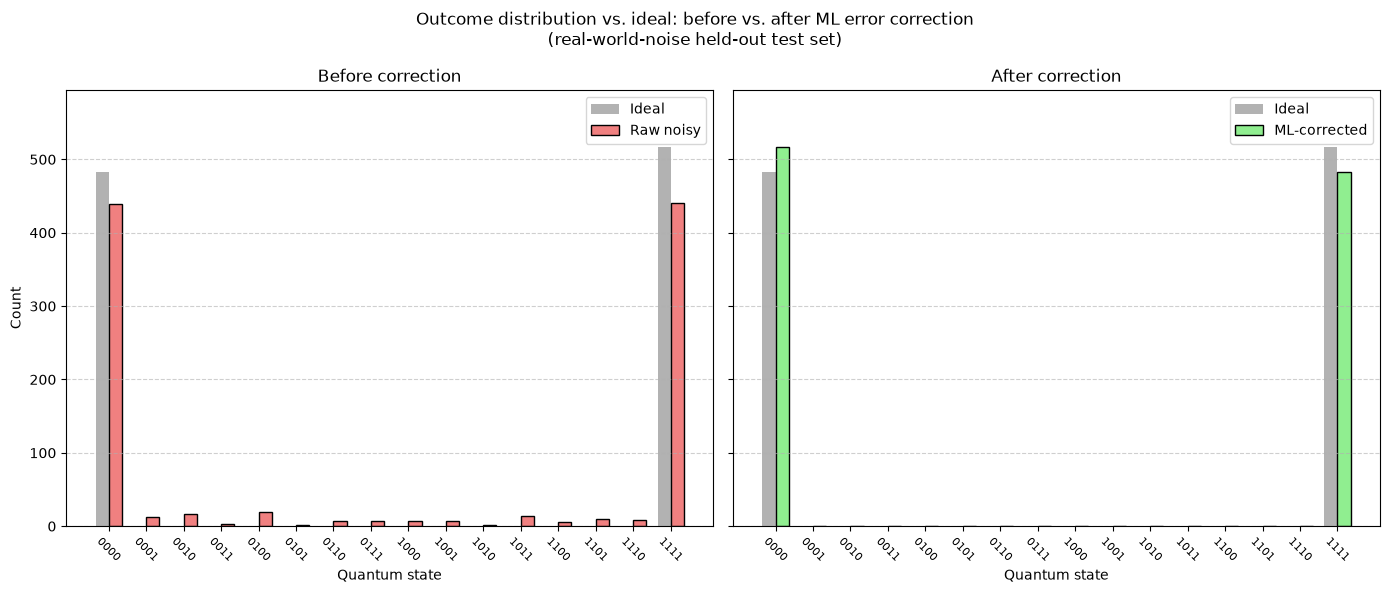

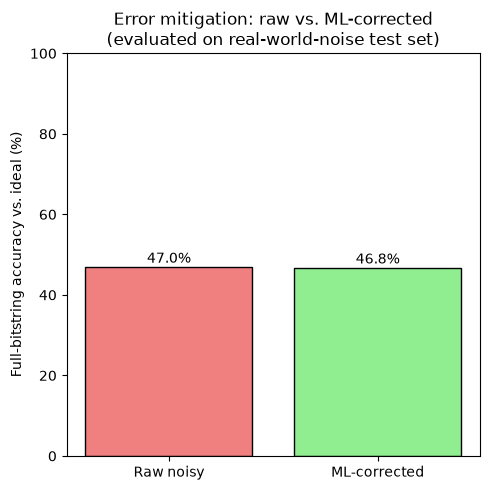

7 

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       44.30%
Model-corrected bitstring accuracy: 50.90%
Improvement:                        +6.60 percentage points

  qubit 0: raw=50.80%  corrected=50.90%
  qubit 1: raw=51.30%  corrected=50.90%
  qubit 2: raw=51.50%  corrected=50.90%
  qubit 3: raw=50.50%  corrected=50.90%


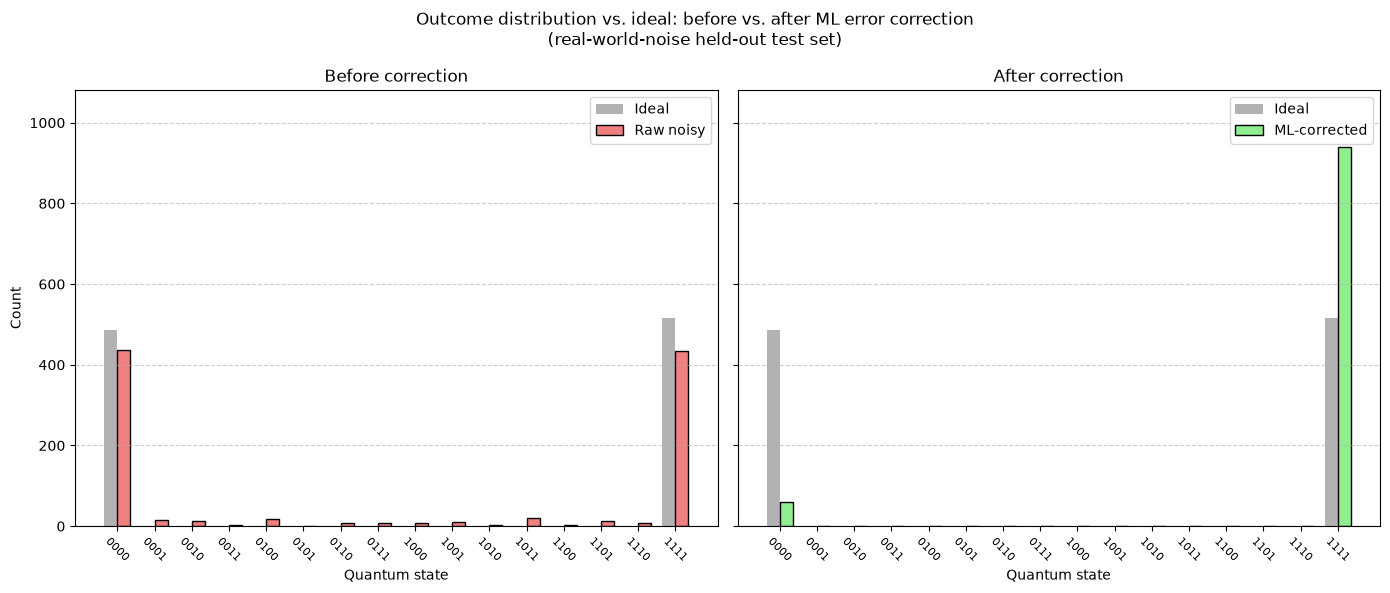

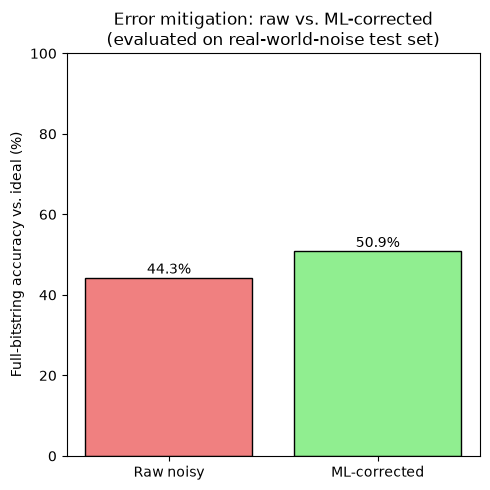

50 

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       43.20%
Model-corrected bitstring accuracy: 50.50%
Improvement:                        +7.30 percentage points

  qubit 0: raw=49.30%  corrected=50.50%
  qubit 1: raw=49.70%  corrected=50.50%
  qubit 2: raw=48.60%  corrected=50.50%
  qubit 3: raw=48.50%  corrected=50.50%


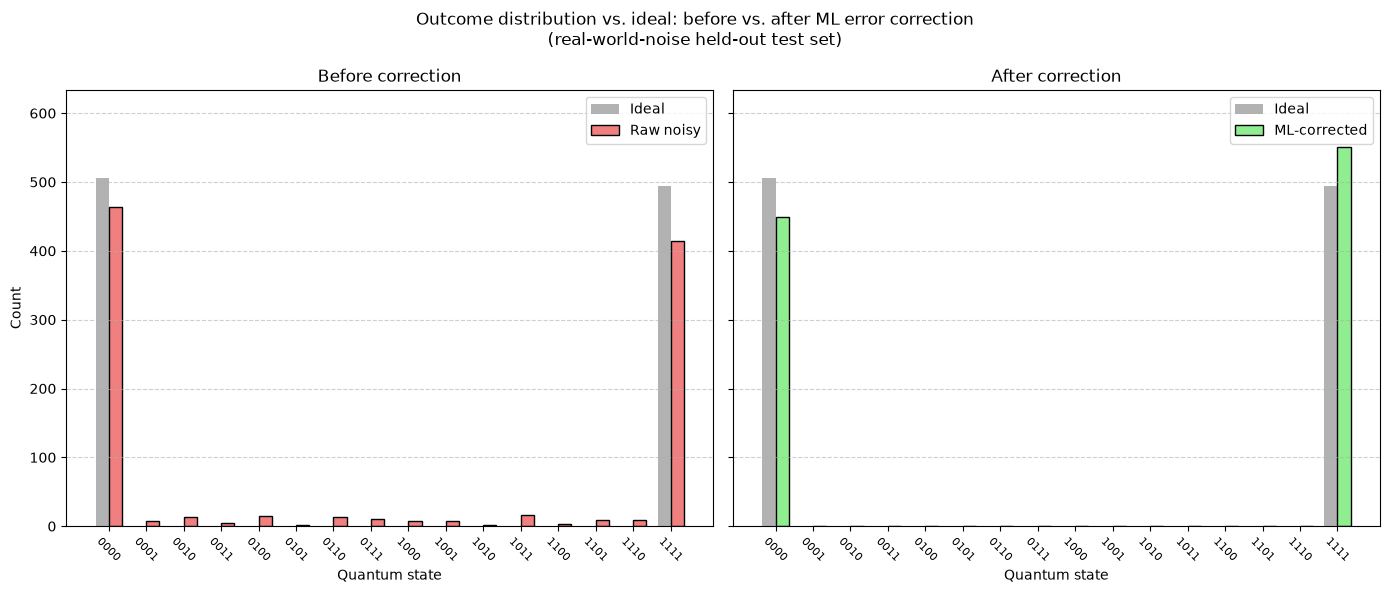

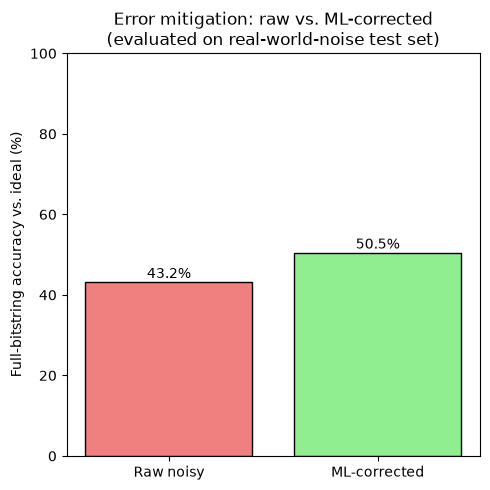

100 

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       44.20%
Model-corrected bitstring accuracy: 51.20%
Improvement:                        +7.00 percentage points

  qubit 0: raw=50.00%  corrected=51.20%
  qubit 1: raw=49.90%  corrected=51.20%
  qubit 2: raw=50.20%  corrected=51.20%
  qubit 3: raw=50.90%  corrected=51.20%


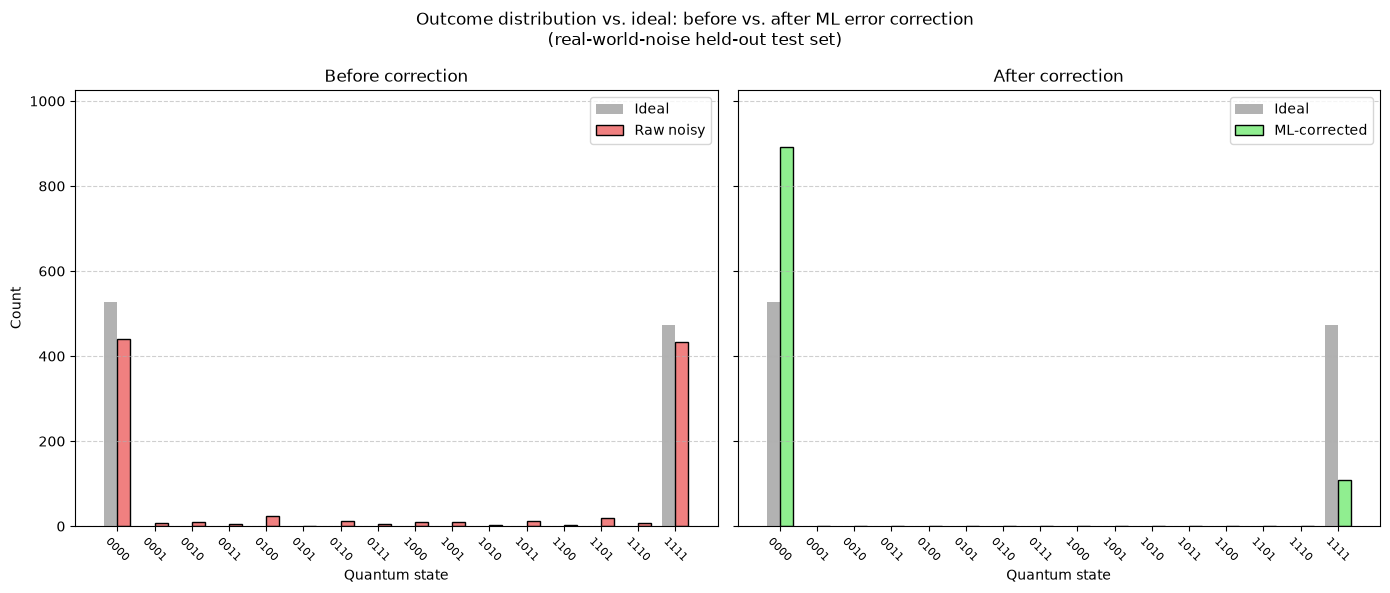

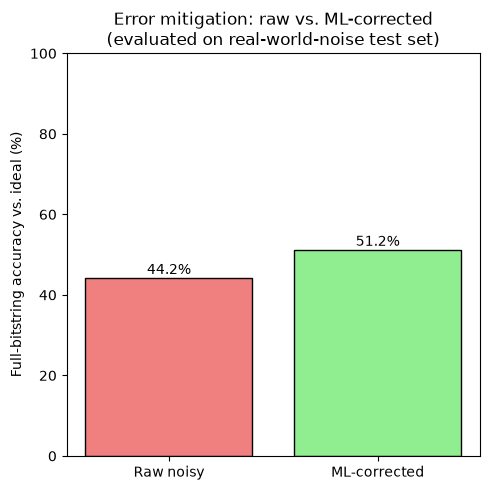

200 

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       43.50%
Model-corrected bitstring accuracy: 49.70%
Improvement:                        +6.20 percentage points

  qubit 0: raw=50.70%  corrected=49.70%
  qubit 1: raw=50.30%  corrected=49.70%
  qubit 2: raw=50.20%  corrected=49.70%
  qubit 3: raw=49.80%  corrected=49.70%


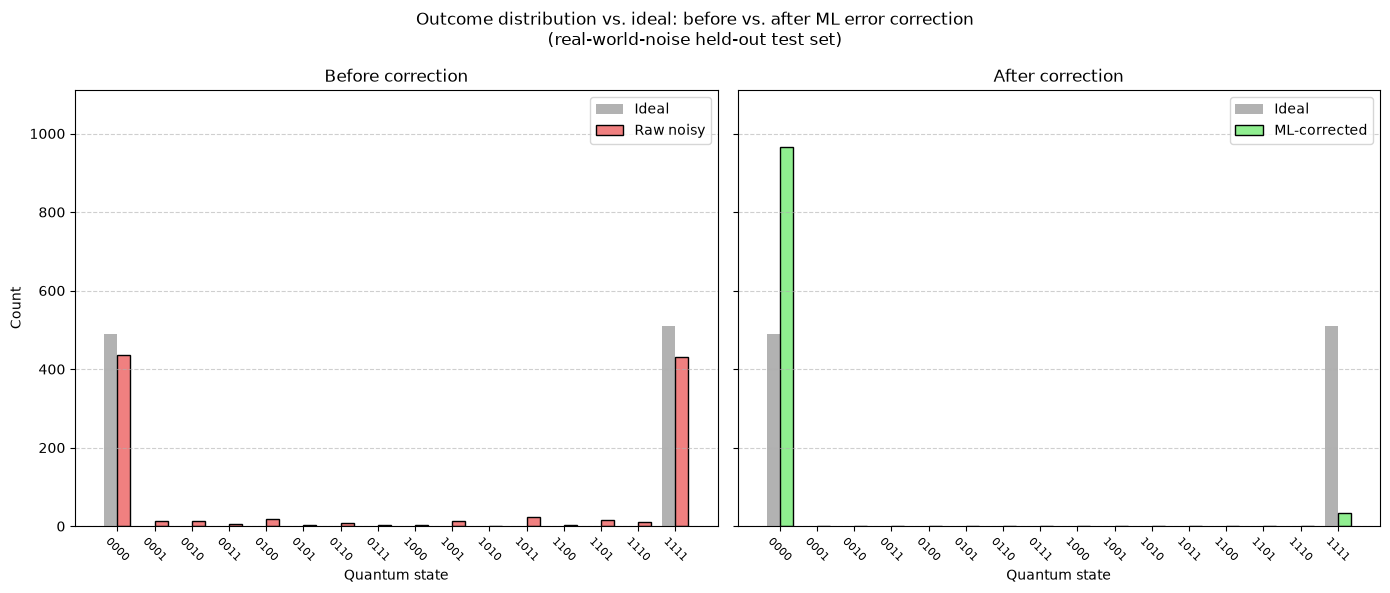

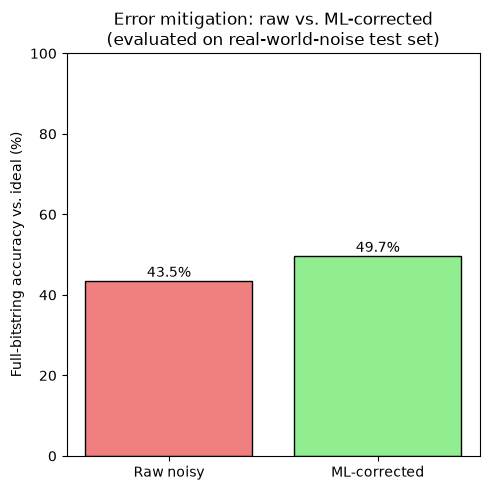

In [ ]:
choices = (1,7,50,100,200)
for num in range(len(choices)):
  RANDOM_SEED = choices[num]
  print(RANDOM_SEED,'\n')
  main()


---
# Generate Grovers algorithm
---

In [130]:
import math
number_choices = 8
correct_choice = 2

"Get qubits to use in the circuit for Grover's algorithm."
nqubits = 3

def generate_binary_strings(number_choices):
    n = int(math.log(number_choices,2))
    binary_strings = []
    for i in range(2**n):
        binary_string = bin(i)[2:].zfill(n)
        binary_strings.append(binary_string)
    return binary_strings

ls = generate_binary_strings(number_choices)
print(ls)

def make_oracle(qubits, ancilla, marked_bitstring):
    """Implements the function {f(x) = 1 if x == x', f(x) = 0 if x != x'}."""
    # For x' = (1, 1), the oracle is just a Toffoli gate.
    # For a general x', we negate the zero bits and implement a Toffoli.

    # Negate zero bits, if necessary.
    for (q, bit) in zip(qubits, marked_bitstring):
        if not bit:
            yield (cirq.X(q))
    # Do the Toffoli. change this to MCX for a generalized oracle
    #yield (cirq.TOFFOLI(qubits[0], qubits[1], ancilla))
    # controls = len(qubits) -1
    controls = len(qubits)
    mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
    yield (mcx_gate(*qubits, ancilla))

    # Negate zero bits, if necessary.
    for (q, bit) in zip(qubits, marked_bitstring):
        if not bit:
            yield (cirq.X(q))

def grover_iteration(qubits, ancilla, marked_bitstring, reps=2):
    """Performs one round of the Grover iteration."""
    circuit = cirq.Circuit()

    # Create an equal superposition over input qubits.
    circuit.append(cirq.H.on_each(*qubits))

    # Put the output qubit in the |-⟩ state.
    circuit.append([cirq.X(ancilla), cirq.H(ancilla)])
    for r in range(reps):
        # Query the oracle.
        # circuit.append(oracle)
        for (q, bit) in zip(qubits, marked_bitstring):
            if not bit:
                circuit.append([cirq.X(q)])
        # Do the Toffoli. change this to MCX for a generalized oracle
        #yield (cirq.TOFFOLI(qubits[0], qubits[1], ancilla))
        # controls = len(qubits) -1
        controls = len(qubits)
        mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
        circuit.append([mcx_gate(*qubits, ancilla)])

        # Negate zero bits, if necessary.
        for (q, bit) in zip(qubits, marked_bitstring):
            if not bit:
                circuit.append([cirq.X(q)])

        # Construct Grover operator.
        circuit.append(cirq.H.on_each(*qubits))
        circuit.append(cirq.X.on_each(*qubits))

        # circuit.append(cirq.H.on(qubits[-1]))
        controls = len(qubits)
        mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
        mcx_op = mcx_gate(*qubits, ancilla)
        circuit.append(mcx_op)
        # circuit.append(cirq.H.on(qubits[-1]))

        circuit.append(cirq.X.on_each(*qubits))
        circuit.append(cirq.H.on_each(*qubits))

    # Measure the input register.
    circuit.append(cirq.measure(*qubits, key="result"))

    return circuit

# Get qubit registers.
qubits = cirq.LineQubit.range(nqubits)
ancilla = cirq.NamedQubit('Ancilla')

def get_marked_bitstring(correct_choice, nqubits):
    binary_representation = list(bin(correct_choice)[2:])
    marked_bitstring = [eval(i) for i in binary_representation]
    desired_length = nqubits
    marked_bitstring = [0] * (desired_length - len(marked_bitstring)) + marked_bitstring
    return marked_bitstring

marked_bitstring = get_marked_bitstring(correct_choice, nqubits)

# Make oracle (black box)
oracle = make_oracle(qubits, ancilla, marked_bitstring)

# Embed the oracle into a quantum circuit implementing Grover's algorithm.
circuit = grover_iteration(qubits, ancilla, marked_bitstring)

"""Simulate the circuit for Grover's algorithm and check the output."""
# Helper function.
def bitstring(bits):
    return "".join(str(int(b)) for b in bits)

def binary_labels(num_qubits):
    return [bin(x)[2:].zfill(num_qubits) for x in range(2 ** num_qubits)]

# Sample from the circuit a couple times.
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions = 1024)

# Look at the sampled bitstrings.
frequencies = result.histogram(key="result", fold_func=bitstring)
print('Sampled results:\n{}'.format(frequencies))

# Check if we actually found the secret value.
most_common_bitstring = frequencies.most_common(1)[0][0]
print("\nMost common bitstring: {}".format(most_common_bitstring))
print("Found a match? {}".format(most_common_bitstring == bitstring(marked_bitstring)))

"""Create the circuit for Grover's algorithm."""

# Embed the oracle into a quantum circuit implementing Grover's algorithm.
circuit = grover_iteration(qubits, ancilla, marked_bitstring)
print("Circuit for Grover's algorithm:")
print(circuit)


['000', '001', '010', '011', '100', '101', '110', '111']
Sampled results:
Counter({'010': 968, '001': 11, '101': 10, '011': 10, '110': 8, '000': 8, '100': 6, '111': 3})

Most common bitstring: 010
Found a match? True
Circuit for Grover's algorithm:
0: ─────────H───X───@───X───H───X───@───X───H───X───@───X───H───X───@───X───H───M('result')───
                    │               │               │               │           │
1: ─────────H───────@───H───X───────@───X───H───────@───H───X───────@───X───H───M─────────────
                    │               │               │               │           │
2: ─────────H───X───@───X───H───X───@───X───H───X───@───X───H───X───@───X───H───M─────────────
                    │               │               │               │
Ancilla: ───X───H───X───────────────X───────────────X───────────────X─────────────────────────


In [131]:
base_circuit = circuit

# Testing Below working so far

In [95]:
qubits = cirq.LineQubit.range(2)
base_circuit = cirq.Circuit([
cirq.X(qubits[0]),
cirq.CNOT(qubits[0],qubits[1]),


cirq.measure(qubits, key="result"),])
print(base_circuit)

0: ───X───@───M('result')───
          │   │
1: ───────X───M─────────────


---
#Machine learning function


your circuit 

0: ─────────H───X───@───X───H───X───@───X───H───X───@───X───H───X───@───X───H───M('result')───
                    │               │               │               │           │
1: ─────────H───────@───H───X───────@───X───H───────@───H───X───────@───X───H───M─────────────
                    │               │               │               │           │
2: ─────────H───X───@───X───H───X───@───X───H───X───@───X───H───X───@───X───H───M─────────────
                    │               │               │               │
Ancilla: ───X───H───X───────────────X───────────────X───────────────X─────────────────────────

EXACT ideal-circuit distribution (analytic, not sampled)...
  |000>: 0.0078
  |001>: 0.0078
  |010>: 0.9453
  |011>: 0.0078
  |100>: 0.0078
  |101>: 0.0078
  |110>: 0.0078
  |111>: 0.0078
  ideal-distribution sanity check passed (max gap vs 3000-shot sampling: 0.003)

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mim

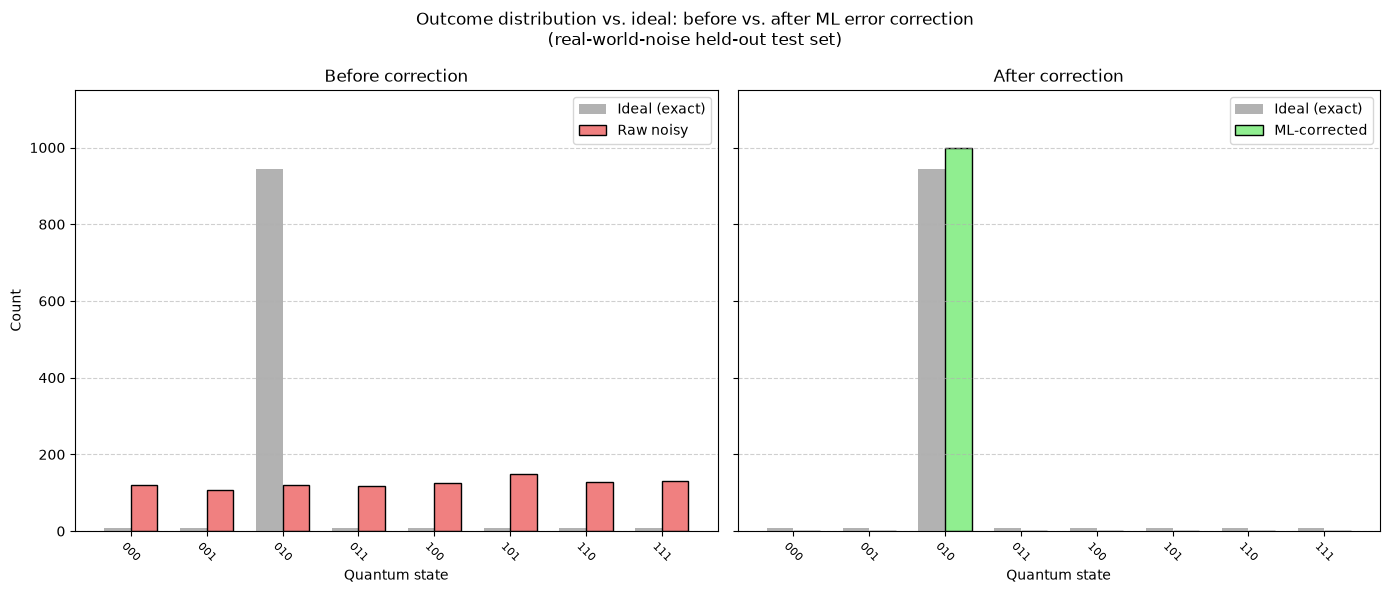

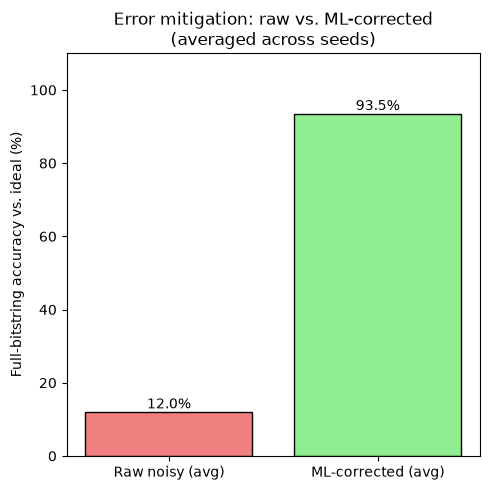

In [143]:
from __future__ import annotations

import itertools
from dataclasses import dataclass

import cirq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SINGLE_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
)
MULTI_GATE_TYPES = (
    cirq.CXPowGate,
    cirq.CYPowGate,
    cirq.CZPowGate,
    cirq.XXPowGate,
    cirq.YYPowGate,
    cirq.ZZPowGate,
    cirq.CCNotPowGate,
    cirq.CCXPowGate,
    cirq.CCYPowGate,
    cirq.CCZPowGate,
    cirq.ISwapPowGate,
    cirq.SwapPowGate,
)

# This still fixes ordinary randomness (data generation, train/holdout
# split, class balancing, classifier init) for a single reproducible run in `main()`.
# The `evaluate_across_seeds()` function now handles aggregating results over multiple seeds
# to produce a more robust overall graph, making the single RANDOM_SEED less impactful on the final aggregated plots.
RANDOM_SEED = 1


@dataclass
class NoiseConfig:
    name: str
    base_noise: float          # background error rate on idle qubits
    single_gate_noise: float
    multi_gate_noise: float
    readout_noise: float
    amplitude_damp_chance: float
    distance_between_qubits: float  # micrometers; smaller = stronger crosstalk


LOW_NOISE_CONFIG = NoiseConfig(
    name="low_noise_baseline",
    base_noise=0.00005,
    single_gate_noise=0.0002,
    multi_gate_noise=0.002,
    readout_noise=0.00077,
    amplitude_damp_chance=0.00002,
    distance_between_qubits=4,
)

REAL_WORLD_CONFIG = NoiseConfig(
    name="real_world_nisq",
    base_noise=0.02,
    single_gate_noise=0.1,
    multi_gate_noise=0.15,
    readout_noise=0.15,
    amplitude_damp_chance=0.001,
    distance_between_qubits=2,
)


# ================= Example circuit =================


# ================= Noise + crosstalk model =================
def build_shot_circuit(original_circuit, all_qubits, config: NoiseConfig):
    """Builds one noisy shot circuit under the given NoiseConfig."""
    circuit = cirq.Circuit()
    for moment in original_circuit:
        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            if config.readout_noise > 0:
                circuit.append(cirq.bit_flip(config.readout_noise).on_each(all_qubits))
            circuit.append(moment)
            continue

        circuit.append(moment)

        single_gate_qubits = {
            q for op in moment if isinstance(op.gate, SINGLE_GATE_TYPES) for q in op.qubits
        }
        multi_gate_qubits = {
            q for op in moment if isinstance(op.gate, MULTI_GATE_TYPES) for q in op.qubits
        }

        depolarize_ops, flipped_qubit_indices = [], []
        for q_idx, q in enumerate(all_qubits):
            if q in single_gate_qubits:
                rate = config.single_gate_noise
            elif q in multi_gate_qubits:
                rate = config.multi_gate_noise
            else:
                rate = config.base_noise

            depolarize_ops.append(cirq.depolarize(p=rate)(q))
            if np.random.rand() < rate:
                flipped_qubit_indices.append(q_idx)

        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(config.amplitude_damp_chance)(q) for q in all_qubits))

        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0
            elif flipped_qubit_indices:
                distances = [
                    abs(q_idx - flipped_idx) * config.distance_between_qubits
                    for flipped_idx in flipped_qubit_indices
                ]
                shortest = max(min(distances), 1e-9)
                crosstalk_p = min(1.0, 1.0 / (shortest ** 2))
            else:
                crosstalk_p = 0.0
            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))

    return circuit


# ================= NEW: exact ideal-circuit distribution =================
def compute_ideal_distribution(base_circuit, measured_qubits):
    """
    This is the actual answer to "check how many correct states there are,
    based off the ideal circuit": instead of estimating the ideal
    distribution by sampling (which is itself noisy for small sample
    counts, and is what made results depend on which seed you happened to
    use), compute it EXACTLY from the circuit's wavefunction. For a Bell
    circuit this returns {00: 0.5, 01: 0.0, 10: 0.0, 11: 0.5} -- not an
    estimate, the literal Born-rule probability.

    Handles circuits with unmeasured "helper" qubits by marginalizing them
    out, and doesn't assume `measured_qubits` is in any particular order
    relative to the circuit's internal qubit ordering.

    Returns: {state_index: probability}, where state_index encodes
    `measured_qubits` in the same bit order cirq.measure(...) reports them.
    """
    circuit_no_measurement = cirq.Circuit(
        op for op in base_circuit.all_operations() if not isinstance(op.gate, cirq.MeasurementGate)
    )
    # Ensure the simulator considers all qubits from the original circuit,
    # including those that are idle but measured, to get a consistent qubit_map.
    all_circuit_qubits = sorted(base_circuit.all_qubits())
    result = cirq.Simulator().simulate(circuit_no_measurement, qubit_order=all_circuit_qubits)

    qubit_map = result.qubit_map
    num_qubits_total = len(all_circuit_qubits) # This now matches the size of the state vector

    probs_tensor = np.abs(result.final_state_vector.reshape((2,) * num_qubits_total)) ** 2

    # measured_axes should now correctly map because qubit_map includes all qubits.
    measured_axes = [qubit_map[q] for q in measured_qubits]
    unmeasured_axes = tuple(ax for ax in range(num_qubits_total) if ax not in measured_axes)
    marginal = probs_tensor.sum(axis=unmeasured_axes) if unmeasured_axes else probs_tensor

    # After summing out unmeasured axes, the remaining axes keep their
    # original relative order -- permute them to match `measured_qubits`.
    remaining_axes_sorted = sorted(measured_axes)
    perm = [remaining_axes_sorted.index(qubit_map[q]) for q in measured_qubits]
    marginal = np.transpose(marginal, axes=perm)

    ideal_probs = {}
    for combo in itertools.product([0, 1], repeat=len(measured_qubits)):
        state_index = int("".join(map(str, combo)), 2)
        ideal_probs[state_index] = float(marginal[combo])
    return ideal_probs


def sanity_check_ideal_distribution(base_circuit, ideal_probs, num_measured_qubits, num_checks=3000):
    """
    Cross-checks compute_ideal_distribution()'s exact answer against a
    large empirical sample from the SAME circuit, as a guardrail: if your
    circuit's structure ever confuses the marginalization logic above
    (e.g. an unusual qubit ordering), this will flag it instead of silently
    feeding a wrong target distribution into training.
    """
    sim = cirq.Simulator()
    samples = np.array([sim.run(base_circuit).measurements["result"][0] for _ in range(num_checks)])
    empirical_counts = np.bincount(bits_to_state_indices(samples), minlength=2 ** num_measured_qubits)
    empirical_probs = empirical_counts / empirical_counts.sum()
    analytic_probs = np.array([ideal_probs.get(i, 0.0) for i in range(2 ** num_measured_qubits)])
    max_gap = float(np.max(np.abs(empirical_probs - analytic_probs)))
    if max_gap > 0.05:
        print(f"  [warning] analytic ideal distribution vs {num_checks}-shot empirical check: "
              f"max gap {max_gap:.3f} -- double-check compute_ideal_distribution() for this circuit.")
    else:
        print(f"  ideal-distribution sanity check passed (max gap vs {num_checks}-shot sampling: {max_gap:.3f})")


# ================= Dataset generation =================
def generate_dataset(base_circuit, qubits, config: NoiseConfig, num_samples: int, ideal_simulator=None):
    """
    Returns (X, y):
      X = [base_noise, single_gate_noise, multi_gate_noise, readout_noise,
           amplitude_damp_chance, distance_between_qubits, *noisy_bitstring]
      y = ideal_bitstring (ground truth, from the noiseless circuit)
    """
    ideal_simulator = ideal_simulator or cirq.Simulator()
    noisy_simulator = cirq.Simulator()
    config_features = [
        config.base_noise,
        config.single_gate_noise,
        config.multi_gate_noise,
        config.readout_noise,
        config.amplitude_damp_chance,
        config.distance_between_qubits,
    ]

    X_rows, y_rows = [], []
    for _ in range(num_samples):
        shot_circuit = build_shot_circuit(base_circuit, qubits, config)
        noisy_bits = noisy_simulator.run(shot_circuit).measurements["result"][0]
        ideal_bits = ideal_simulator.run(base_circuit).measurements["result"][0]

        X_rows.append(config_features + list(noisy_bits))
        y_rows.append(list(ideal_bits))

    return np.array(X_rows, dtype=float), np.array(y_rows, dtype=float)


def bitstring_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Fraction of samples where EVERY bit matches the ideal bitstring."""
    return float(np.mean(np.all(y_true == y_pred, axis=1)))


def per_bit_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    return np.mean(y_true == y_pred, axis=0)


def bits_to_state_indices(bit_rows: np.ndarray) -> np.ndarray:
    num_qubits = bit_rows.shape[1]
    weights = 2 ** np.arange(num_qubits - 1, -1, -1)
    return bit_rows.astype(int).dot(weights)


def state_indices_to_bits(state_indices: np.ndarray, num_qubits: int) -> np.ndarray:
    rows = [[int(b) for b in format(int(idx), f"0{num_qubits}b")] for idx in state_indices]
    return np.array(rows, dtype=float)


def balance_classes_uniform(X: np.ndarray, y_labels: np.ndarray, random_state: int = 0):
    """
    ORIGINAL approach, kept for comparison: oversamples every OBSERVED
    class up to the same count. This silently assumes the ideal circuit's
    true distribution is uniform across whichever outcomes happened to
    show up in this batch of training data -- true for a Bell state (its
    two live outcomes really are 50/50), but wrong for any circuit whose
    ideal distribution is genuinely skewed.
    """
    rng = np.random.default_rng(random_state)
    unique_labels, counts = np.unique(y_labels, return_counts=True)
    target_count = counts.max()
    balanced_idx = []
    for label in unique_labels:
        idx_for_label = np.where(y_labels == label)[0]
        balanced_idx.append(rng.choice(idx_for_label, size=target_count, replace=True))
    balanced_idx = np.concatenate(balanced_idx)
    rng.shuffle(balanced_idx)
    return X[balanced_idx], y_labels[balanced_idx]


def reweight_to_ideal_distribution(X: np.ndarray, y_labels: np.ndarray, ideal_probs: dict, random_state: int = 0):
    """
    NEW: resamples each class to match its EXACT analytic probability
    under the ideal circuit (from compute_ideal_distribution), instead of
    forcing every class to the same count. This is what actually answers
    "use the ideal circuit's true state counts to correct the data
    properly": the training data's class balance now reflects real physics
    instead of (a) whatever ratio randomly showed up in this batch, or
    (b) an assumed-uniform prior that's wrong for asymmetric circuits.
    A class with truly zero ideal probability (like |01>/|10> for a Bell
    state) still gets a token few samples so the model can learn to
    correct noise-only errors, but is never inflated to look as likely as
    a real outcome.
    """
    rng = np.random.default_rng(random_state)
    unique_labels, counts = np.unique(y_labels, return_counts=True)
    total = int(counts.sum())

    balanced_idx = []
    for label in unique_labels:
        p = ideal_probs.get(int(label), 0.0)
        target_count = max(1, round(p * total)) if p > 0 else min(counts[unique_labels == label][0], 5)
        idx_for_label = np.where(y_labels == label)[0]
        balanced_idx.append(rng.choice(idx_for_label, size=target_count, replace=True))
    balanced_idx = np.concatenate(balanced_idx)
    rng.shuffle(balanced_idx)
    return X[balanced_idx], y_labels[balanced_idx]


def total_variation_distance(observed_counts: np.ndarray, ideal_probs: dict, num_states: int) -> float:
    """
    How far an empirical outcome distribution is from the circuit's EXACT
    analytic distribution (0 = identical, 1 = maximally different). This
    is a better "how close to ideal" metric than raw bitstring accuracy
    against a finite, noisy test set, because it's compared against the
    true Born-rule probabilities rather than one particular noisy sample.
    """
    observed_probs = observed_counts / observed_counts.sum()
    ideal_vec = np.array([ideal_probs.get(s, 0.0) for s in range(num_states)])
    return 0.5 * float(np.sum(np.abs(observed_probs - ideal_vec)))


def plot_before_after_histograms(y_true_test, y_noisy, y_corrected, num_qubits, ideal_probs):
    num_states = 2 ** num_qubits
    labels = [format(i, f"0{num_qubits}b") for i in range(num_states)]

    noisy_counts = np.bincount(bits_to_state_indices(y_noisy), minlength=num_states)
    corrected_counts = np.bincount(bits_to_state_indices(y_corrected), minlength=num_states)

    # Calculate ideal reference counts from ideal_probs, scaled to the total number of corrected samples
    ideal_reference_counts = np.array([ideal_probs.get(i, 0.0) for i in range(num_states)]) * corrected_counts.sum()

    y_max = max(ideal_reference_counts.max(), noisy_counts.max(), corrected_counts.max()) * 1.15
    x = np.arange(num_states)
    width = 0.35

    fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax_before.bar(x - width / 2, ideal_reference_counts, width, label="Ideal (exact)", color="gray", alpha=0.6)
    ax_before.bar(x + width / 2, noisy_counts, width, label="Raw noisy", color="lightcoral", edgecolor="black")
    ax_before.set_title("Before correction")
    ax_before.set_xlabel("Quantum state")
    ax_before.set_ylabel("Count")
    ax_before.set_xticks(x)
    ax_before.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_before.set_ylim(0, y_max)
    ax_before.legend()
    ax_before.grid(axis="y", linestyle="--", alpha=0.6)

    ax_after.bar(x - width / 2, ideal_reference_counts, width, label="Ideal (exact)", color="gray", alpha=0.6)
    ax_after.bar(x + width / 2, corrected_counts, width, label="ML-corrected", color="lightgreen", edgecolor="black")
    ax_after.set_title("After correction")
    ax_after.set_xlabel("Quantum state")
    ax_after.set_xticks(x)
    ax_after.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_after.legend()
    ax_after.grid(axis="y", linestyle="--", alpha=0.6)

    fig.suptitle("Outcome distribution vs. ideal: before vs. after ML error correction\n(real-world-noise held-out test set)")
    plt.tight_layout()
    plt.show()


# ================= robustness check across seeds =================
def evaluate_across_seeds(base_circuit, qubits, measured_qubits, ideal_probs, seeds=range(1)):

    num_measured = len(measured_qubits)
    raw_accs, corrected_accs, tvds = [], [], []

    all_y_real_test = []
    all_noisy_bits_test = []
    all_corrected_bits_test = []

    for seed in seeds:
        np.random.seed(seed)
        # Increased sample sizes to prevent ValueError in train_test_split due to stratification
        X_low, y_low = generate_dataset(base_circuit, qubits, LOW_NOISE_CONFIG, num_samples=2400, ideal_simulator=None)
        X_real_train, y_real_train = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=600, ideal_simulator=None)
        X_real_test, y_real_test = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=1000, ideal_simulator=None)

        X_train = np.vstack([X_low, X_real_train])
        y_train = np.vstack([y_low, y_real_train])
        y_train_labels_full = bits_to_state_indices(y_train)
        X_train, _, y_train, _ = train_test_split(
            X_train, y_train, test_size=0.15, random_state=seed, stratify=y_train_labels_full
        )
        y_train_labels = bits_to_state_indices(y_train)
        X_bal, y_bal = reweight_to_ideal_distribution(X_train, y_train_labels, ideal_probs, random_state=seed)

        model = make_pipeline(
            StandardScaler(), MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=seed)
        )
        model.fit(X_bal, y_bal)

        noisy_bits_test = X_real_test[:, -num_measured:]
        raw_acc = bitstring_accuracy(y_real_test, noisy_bits_test)
        corrected_labels = model.predict(X_real_test)
        corrected_bits = state_indices_to_bits(corrected_labels, num_measured)
        corrected_acc = bitstring_accuracy(y_real_test, corrected_bits)

        corrected_counts = np.bincount(bits_to_state_indices(corrected_bits), minlength=2 ** num_measured)
        tvd = total_variation_distance(corrected_counts, ideal_probs, num_states=2 ** num_measured)

        raw_accs.append(raw_acc)
        corrected_accs.append(corrected_acc)
        tvds.append(tvd)

        all_y_real_test.append(y_real_test)
        all_noisy_bits_test.append(noisy_bits_test)
        all_corrected_bits_test.append(corrected_bits)

    raw_accs, corrected_accs, tvds = (np.array(a) for a in (raw_accs, corrected_accs, tvds))
    print(f"\n=== Robustness check across {len(list(seeds))} independent seeds ===")
    print(f"Raw noisy accuracy:        {raw_accs.mean()*100:5.2f}%  (std {raw_accs.std()*100:4.2f})")
    print(f"ML-corrected accuracy:     {corrected_accs.mean()*100:5.2f}%  (std {corrected_accs.std()*100:4.2f})")
    print(f"TVD to exact ideal dist.:  {tvds.mean():.4f}  (std {tvds.std():.4f})")

    # Aggregate and plot results across all seeds
    print("\nPlotting aggregated results across all seeds...")
    aggregated_y_real_test = np.vstack(all_y_real_test)
    aggregated_noisy_bits_test = np.vstack(all_noisy_bits_test)
    aggregated_corrected_bits_test = np.vstack(all_corrected_bits_test)

    plot_before_after_histograms(
        aggregated_y_real_test,
        aggregated_noisy_bits_test,
        aggregated_corrected_bits_test,
        num_measured,
        ideal_probs=ideal_probs
    )

    return raw_accs, corrected_accs, tvds


# ================= Main training + evaluation pipeline =================
def main():
    np.random.seed(RANDOM_SEED)


    print(f"your circuit \n\n{base_circuit}\n")
    ideal_sim = cirq.Simulator()

    measured_qubits = [
        q for op in base_circuit.all_operations() if isinstance(op.gate, cirq.MeasurementGate) for q in op.qubits
    ]
    num_measured_qubits = len(measured_qubits)

    print("EXACT ideal-circuit distribution (analytic, not sampled)...")
    ideal_probs = compute_ideal_distribution(base_circuit, measured_qubits)
    for state_idx, p in ideal_probs.items():
        print(f"  |{format(state_idx, f'0{num_measured_qubits}b')}>: {p:.4f}")
    sanity_check_ideal_distribution(base_circuit, ideal_probs, num_measured_qubits)

    print("\nGenerating LOW-noise training data (clean baseline)...")
    X_low, y_low = generate_dataset(base_circuit, qubits, LOW_NOISE_CONFIG, num_samples=480, ideal_simulator=ideal_sim)

    print("Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...")
    X_real_train, y_real_train = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=120, ideal_simulator=ideal_sim)

    print("Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...")
    X_real_test, y_real_test = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=200, ideal_simulator=ideal_sim)

    X_train = np.vstack([X_low, X_real_train])
    y_train = np.vstack([y_low, y_real_train])
    y_train_labels_full = bits_to_state_indices(y_train)
    X_train, X_holdout, y_train, y_holdout = train_test_split(
        X_train, y_train, test_size=0.15, random_state=0, stratify=y_train_labels_full
    )

    print(f"\nTraining samples: {len(X_train)}  (holdout: {len(X_holdout)}, real-world test: {len(X_real_test)})")

    print("Training MLP error-mitigation model...")
    y_train_labels = bits_to_state_indices(y_train)

    # CHANGED: resample toward the EXACT ideal distribution instead of
    # forcing every observed class to the same count.
    X_train_balanced, y_train_labels_balanced = reweight_to_ideal_distribution(
        X_train, y_train_labels, ideal_probs, random_state=0
    )

    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=0),
    )
    model.fit(X_train_balanced, y_train_labels_balanced)

    noisy_bits_test = X_real_test[:, -num_measured_qubits:]
    raw_acc = bitstring_accuracy(y_real_test, noisy_bits_test)

    corrected_labels_test = model.predict(X_real_test)
    corrected_bits_test = state_indices_to_bits(corrected_labels_test, num_measured_qubits)
    corrected_acc = bitstring_accuracy(y_real_test, corrected_bits_test)

    raw_per_bit = per_bit_accuracy(y_real_test, noisy_bits_test)
    corrected_per_bit = per_bit_accuracy(y_real_test, corrected_bits_test)

    corrected_counts = np.bincount(bits_to_state_indices(corrected_bits_test), minlength=2 ** num_measured_qubits)
    tvd = total_variation_distance(corrected_counts, ideal_probs, num_states=2 ** num_measured_qubits)

    print("\n=== Real-world NISQ evaluation (held-out test set) ===")
    print(f"Raw noisy bitstring accuracy:       {raw_acc * 100:.2f}%")
    print(f"Model-corrected bitstring accuracy: {corrected_acc * 100:.2f}%")
    print(f"Improvement:                        {(corrected_acc - raw_acc) * 100:+.2f} percentage points")
    print(f"TVD of corrected dist. to exact ideal dist.: {tvd:.4f}\n")
    for i in range(num_measured_qubits):
        print(f"  qubit {i}: raw={raw_per_bit[i] * 100:5.2f}%  corrected={corrected_per_bit[i] * 100:5.2f}%")

    # Confirms the single run above isn't a cherry-picked seed.
    # The plot_before_after_histograms call was moved inside evaluate_across_seeds to aggregate results.
    agg_raw_accs, agg_corrected_accs, agg_tvds = evaluate_across_seeds(base_circuit, qubits, measured_qubits, ideal_probs, seeds=range(0,1,1))

    plt.figure(figsize=(5, 5))
    plt.bar(["Raw noisy (avg)", "ML-corrected (avg)"], [agg_raw_accs.mean() * 100, agg_corrected_accs.mean() * 100],
            color=["lightcoral", "lightgreen"], edgecolor="black")
    plt.ylabel("Full-bitstring accuracy vs. ideal (%)")
    plt.title("Error mitigation: raw vs. ML-corrected\n(averaged across seeds)") # Updated title for clarity
    plt.ylim(0, 110)
    for i, v in enumerate([agg_raw_accs.mean() * 100, agg_corrected_accs.mean() * 100]):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()
main()

---
#Run ML algorithm

In [142]:
main()

your circuit 

0: ─────────H───X───@───X───H───X───@───X───H───X───@───X───H───X───@───X───H───M('result')───
                    │               │               │               │           │
1: ─────────H───────@───H───X───────@───X───H───────@───H───X───────@───X───H───M─────────────
                    │               │               │               │           │
2: ─────────H───X───@───X───H───X───@───X───H───X───@───X───H───X───@───X───H───M─────────────
                    │               │               │               │
Ancilla: ───X───H───X───────────────X───────────────X───────────────X─────────────────────────

EXACT ideal-circuit distribution (analytic, not sampled)...
  |000>: 0.0078
  |001>: 0.0078
  |010>: 0.9453
  |011>: 0.0078
  |100>: 0.0078
  |101>: 0.0078
  |110>: 0.0078
  |111>: 0.0078
  ideal-distribution sanity check passed (max gap vs 3000-shot sampling: 0.003)

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mim

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.